# 02 — GWRHelp Intent Taxonomy

Discover, define, and freeze the intent taxonomy from real GWRHelp first-inbound
messages. This notebook does **not** build a classifier, retrieval, replies, or the
golden set. Those live downstream.

Pipeline: explore → candidate intents → overlap review → coverage check
→ examples → freeze (`configs/intents.yaml`) → handoff to `03_golden_set.ipynb`.

In [1]:
# ============ CELL 2: Imports, root discovery, seed, paths ============
from pathlib import Path
import os, re, json, hashlib, subprocess, sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display

# --- Marker-based project root ---
def find_project_root():
    markers = [".git", "pyproject.toml"]
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError(f"Could not locate ResolveIQ project root from {p}")

PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)

# Make src/ importable for downstream reuse.
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# --- Determinism ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Paths ---
BRAND         = "GWRHelp"
RUNS_DIR      = PROJECT_ROOT / "runs" / "taxonomy"
FROZEN_DIR    = RUNS_DIR / "frozen"
CONFIG_DIR    = PROJECT_ROOT / "configs"
REPORTS_FIGS  = PROJECT_ROOT / "reports" / "figures"

for d in (RUNS_DIR, FROZEN_DIR, CONFIG_DIR, REPORTS_FIGS):
    d.mkdir(parents=True, exist_ok=True)
assert os.access(RUNS_DIR, os.W_OK)

FIRST_INBOUND = PROJECT_ROOT / "runs" / "brand_selection" / "first_inbound_per_thread.pkl"
BRAND_CFG     = CONFIG_DIR / "brand.yaml"
assert FIRST_INBOUND.exists(), f"Missing input: {FIRST_INBOUND}"
assert BRAND_CFG.exists(),     f"Missing config: {BRAND_CFG}"

# Deliberate NON-inputs (documented so future readers don't accidentally use them):
#   runs/brand_selection/brand_responses_classified.csv  (heuristic EDA, not GT)
#   evaluation/golden_set.jsonl, human_annotations.csv, judge_agreement.md

PROJECT_ROOT: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ


In [2]:
# ============ CELL 3: Load + schema validation ============
df = pd.read_pickle(FIRST_INBOUND)

REQUIRED_COLS = {"root_id", "brand_author_id", "customer_author_id",
                 "customer_text", "created_at"}
missing = REQUIRED_COLS - set(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

assert df["root_id"].is_unique, "root_id not unique — thread-level assumption broken"
assert df["customer_text"].notna().all(), "Null customer_text"
assert (df["customer_text"].str.strip() != "").all(), "Empty customer_text"

counts = df["brand_author_id"].value_counts()
assert BRAND in counts.index, f"{BRAND} not in dataset. Top: {counts.head(10).to_dict()}"

gwr = df[df["brand_author_id"] == BRAND].copy()
assert len(gwr) > 0, "Empty GWRHelp slice"

print(f"Total threads:   {len(df):,}")
print(f"GWRHelp threads: {len(gwr):,}")
print(f"Columns:         {list(gwr.columns)}")
display(gwr.head(3))

Total threads:   118,101
GWRHelp threads: 1,612
Columns:         ['root_id', 'first_inbound_tweet_id', 'customer_author_id', 'customer_text', 'created_at', 'n_tweets', 'n_inbound', 'n_outbound', 'brand_author_id']


,root_id,first_inbound_tweet_id,customer_author_id,customer_text,created_at,n_tweets,n_inbound,n_outbound,brand_author_id
149,5436,5436,116971,@GWRHelp Hello i’ve left my iphone on the trai...,2017-10-31 23:16:23+00:00,14,6,8,GWRHelp
579,19024,19024,120243,@GWRHelp not a happy #pregnant #commuter 0503 ...,2017-11-01 05:35:26+00:00,3,2,1,GWRHelp
590,19847,19847,120360,Just paid more for a return to Bristol with @G...,2017-11-01 06:32:42+00:00,2,1,1,GWRHelp


Threads:          1,612
Unique customers: 1,428
Median length:    127
Mean length:      128

count    1612.0
mean      128.2
std        46.4
min        20.0
5%         61.0
25%        99.0
50%       127.0
75%       140.0
95%       220.0
99%       275.9
max       301.0
Name: _len, dtype: float64

Very short (<5 chars): 0

Distinct messages appearing >1 time: 0


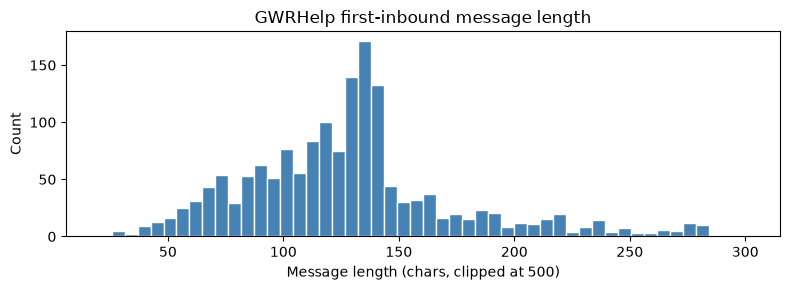

In [3]:
# ============ CELL 4: GWRHelp profile ============
gwr["_len"] = gwr["customer_text"].str.strip().str.len()

print(f"Threads:          {len(gwr):,}")
print(f"Unique customers: {gwr['customer_author_id'].nunique():,}")
print(f"Median length:    {gwr['_len'].median():.0f}")
print(f"Mean length:      {gwr['_len'].mean():.0f}\n")
print(gwr["_len"].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(1))

short = gwr[gwr["_len"] < 5]
print(f"\nVery short (<5 chars): {len(short)}")
if len(short):
    display(short[["root_id", "customer_text"]].head(20))

gwr["_text_key"] = gwr["customer_text"].str.strip().str.lower()
dupes = gwr["_text_key"].value_counts()
n_dup = int((dupes > 1).sum())
print(f"\nDistinct messages appearing >1 time: {n_dup}")
if n_dup:
    display(dupes[dupes > 1].head(10).rename("count").to_frame())

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(gwr["_len"].clip(upper=500), bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Message length (chars, clipped at 500)")
ax.set_ylabel("Count")
ax.set_title("GWRHelp first-inbound message length")
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "taxonomy_msg_length.png", dpi=120)
plt.show()

In [4]:
# ============ CELL 5: Stratified exploration sample ============
def stratified_sample(frame, n=100, seed=RANDOM_STATE):
    """Sample across length quantiles so short messages aren't drowned out."""
    f = frame.copy()
    try:
        f["_bin"] = pd.qcut(f["_len"], q=5, duplicates="drop")
    except ValueError:
        f["_bin"] = 0
    n_bins = f["_bin"].nunique()
    per_bin = max(1, n // n_bins) if n_bins else n
    sampled = (f.groupby("_bin", group_keys=False)
                 .apply(lambda g: g.sample(min(per_bin, len(g)), random_state=seed)))
    return sampled.sample(frac=1, random_state=seed).reset_index(drop=True)

exploration_sample = stratified_sample(gwr, n=min(100, len(gwr)))
exploration_sample[["root_id", "customer_author_id", "created_at", "customer_text"]] \
    .to_csv(RUNS_DIR / "exploration_sample.csv", index=False)

print(f"Wrote exploration sample: {len(exploration_sample)} rows -> "
      f"{RUNS_DIR / 'exploration_sample.csv'}\n")
for i, row in exploration_sample.iterrows():
    text = str(row["customer_text"]).replace("\n", " ").strip()
    print(f"{i+1:3d}. [{row['root_id']}] {text[:240]}")

Wrote exploration sample: 100 rows -> D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\exploration_sample.csv

  1. [2720778] @GWRHelp hi, is it too late to buy a ticket with a seat reservation for peak time out of Paddington tonight? Ticket office closed in bridgend yesterday and this morning so unable to do so. (I know I can buy a ticket, it’s the reservation bi
  2. [1728710] @GWRHelp Hi please can you tell me if the 18.34 Paignton-Exeter st David’s has departed Paignton yet? And if so how delayed is it?
  3. [1827111] @GWRHelp Well I've just arrived at work in Bath Spa - one and a half hours late!!! I had to get a train to Chippenham and a lift via car!
  4. [1203052] On the 1302 Bristol Parkway-London Paddington. But this isn’t any ordinary train... this is @GWRHelp style 😎 https://t.co/tVHyqZaBBl
  5. [71711] @GWRHelp explanation the 9.35 from Langley is now 15 mins late? This service is a joke and shockingly late constantly, not acceptable.
  6. [1801783] Today's trip from Worl

In [5]:
# ============ CELL 6: Normalization + quarantine ============
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE  = re.compile(r"(?<!\w)@\w+")
POSTCODE_RE = re.compile(r"\b[A-Z]{1,2}\d{1,2}\s?\d[A-Z]{2}\b", re.I)
LONGNUM_RE  = re.compile(r"\b\d{6,}\b")
WS_RE       = re.compile(r"\s+")

def normalize_text(text: str, keep_mentions: bool = False) -> str:
    t = str(text).lower()
    t = URL_RE.sub(" ", t)
    if not keep_mentions:
        t = MENTION_RE.sub(" ", t)
    t = POSTCODE_RE.sub(" ", t)
    t = LONGNUM_RE.sub(" ", t)
    t = WS_RE.sub(" ", t)
    return t.strip()

# customer_text is never overwritten. text_norm is for analysis only.
gwr["text_norm"] = gwr["customer_text"].map(normalize_text)

empty_mask = gwr["text_norm"].str.len() == 0
n_empty = int(empty_mask.sum())
print(f"Messages that normalize to empty: {n_empty} / {len(gwr)} "
      f"({n_empty / len(gwr):.2%})")

if n_empty:
    display(gwr.loc[empty_mask, ["root_id", "customer_text"]].head(20))
    gwr.loc[empty_mask, ["root_id", "customer_text"]] \
        .to_csv(RUNS_DIR / "excluded_uninformative_messages.csv", index=False)
    print(f"Wrote: {RUNS_DIR / 'excluded_uninformative_messages.csv'}")

gwr_analysis = gwr.loc[~empty_mask].copy().reset_index(drop=True)
assert len(gwr_analysis) > 0, "Analysis corpus is empty — check normalization regexes"

ok_norm = gwr_analysis["text_norm"]
assert (ok_norm.str.len() > 0).all(), "Non-empty rows regressed"
assert ok_norm.notna().all(),             "Nulls in text_norm after normalization"

print(f"\nAnalysis corpus: {len(gwr_analysis):,} rows "
      f"({len(gwr) - len(gwr_analysis):,} excluded)")

display(gwr_analysis[["customer_text", "text_norm"]]
        .sample(min(5, len(gwr_analysis)), random_state=RANDOM_STATE))

Messages that normalize to empty: 2 / 1612 (0.12%)


,root_id,customer_text
35836,1004064,@GWRHelp https://t.co/70luhi1PO4
107445,2743198,@GWRHelp @44693 @564161 @149529 @433493 https:...


Wrote: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\excluded_uninformative_messages.csv

Analysis corpus: 1,610 rows (2 excluded)


,customer_text,text_norm
29,"@GWRHelp 17:18 from Reigate to Reading, what’s...","17:18 from reigate to reading, what’s going on?"
99,@GWRHelp ticket machine out of service at Brad...,ticket machine out of service at bradford on a...
678,@GWRHelp What is happening with your online bo...,what is happening with your online booking sys...
1399,Long day now even longer as my @GWRHelp train ...,long day now even longer as my train home from...
185,Still in Bristol in Gardiner Haskins (I should...,still in bristol in gardiner haskins (i should...


Analysis corpus size: 1,610
Top 40 by raw frequency:


,count
paddington,222
service,215
late,159
delayed,150
bristol,146
ticket,144
london,134
pad,129
time,126
cancelled,126


Top 40 by mean TF-IDF:


,mean_tfidf
paddington,0.029842
service,0.028329
delayed,0.023033
bristol,0.021414
late,0.020945
time,0.020471
london,0.020286
today,0.020251
cancelled,0.019846
new,0.019739


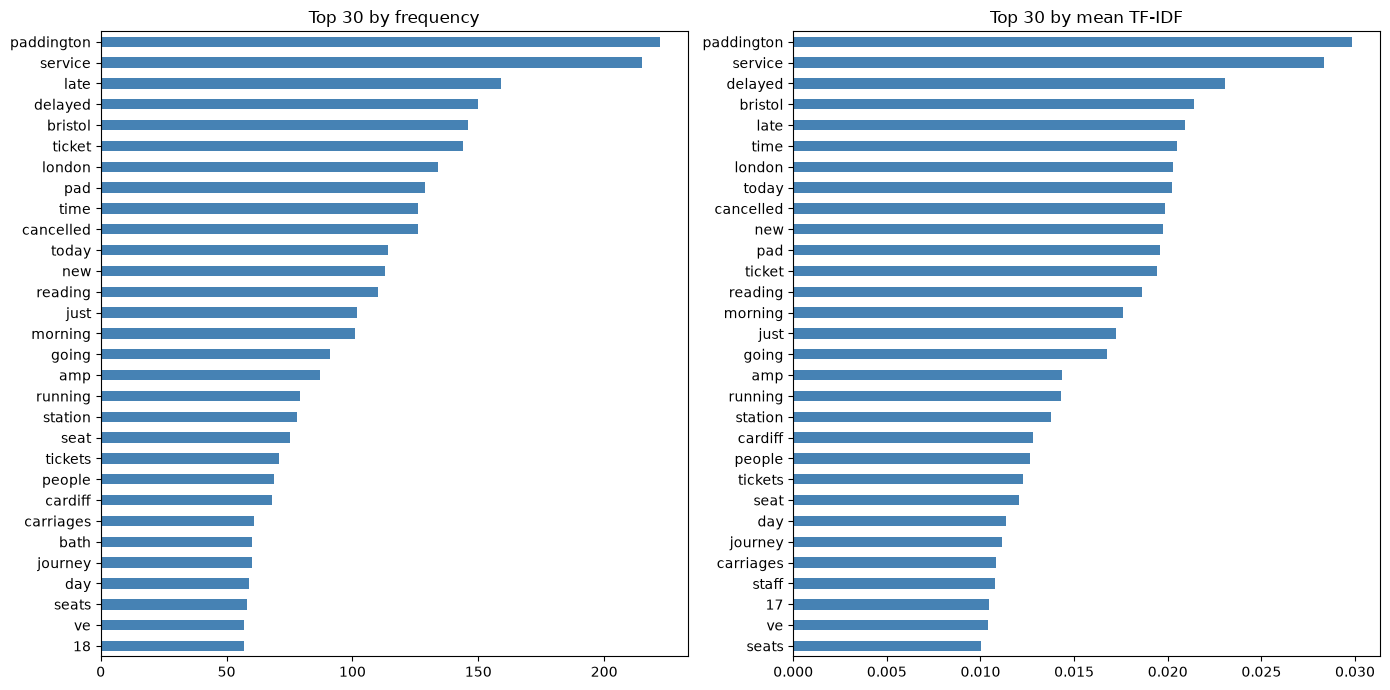

In [6]:
# ============ CELL 7: Frequency + TF-IDF discovery ============
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction import text as sk_text

GWR_STOPWORDS = [
    "gwr", "great", "western", "railway", "train", "trains",
    "please", "thanks", "thank", "hello", "hi", "hey",
    "would", "could", "get", "got", "know", "help",
]
STOPWORDS = list(sk_text.ENGLISH_STOP_WORDS) + GWR_STOPWORDS

corpus = gwr_analysis["text_norm"].tolist()
print(f"Analysis corpus size: {len(corpus):,}")

# 7a. Frequency
cv = CountVectorizer(stop_words=STOPWORDS, ngram_range=(1, 2), min_df=5, max_df=0.5)
Xc = cv.fit_transform(corpus)
freq = (pd.Series(np.asarray(Xc.sum(axis=0)).ravel(),
                  index=cv.get_feature_names_out())
          .sort_values(ascending=False))
print("Top 40 by raw frequency:")
display(freq.head(40).rename("count").to_frame())

# 7b. TF-IDF
tv = TfidfVectorizer(stop_words=STOPWORDS, ngram_range=(1, 2),
                     min_df=5, max_df=0.5, sublinear_tf=True)
Xt = tv.fit_transform(corpus)
tfidf = (pd.Series(np.asarray(Xt.mean(axis=0)).ravel(),
                   index=tv.get_feature_names_out())
           .sort_values(ascending=False))
print("Top 40 by mean TF-IDF:")
display(tfidf.head(40).rename("mean_tfidf").to_frame())

# 7c. Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, s, title in [(axes[0], freq,  "Top 30 by frequency"),
                     (axes[1], tfidf, "Top 30 by mean TF-IDF")]:
    s.head(30)[::-1].plot.barh(ax=ax, color="steelblue")
    ax.set_title(title); ax.set_xlabel("")
plt.tight_layout()
plt.savefig(REPORTS_FIGS / "taxonomy_terms.png", dpi=120)
plt.show()

In [7]:
# ============ CELL 8: Cluster discovery (supporting evidence, NOT taxonomy) ============
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import Normalizer

# Guard n_components against tiny matrices
max_comp = max(2, min(Xt.shape[0], Xt.shape[1]) - 1)
n_comp = min(50, max_comp)
svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
Z = Normalizer(copy=False).fit_transform(svd.fit_transform(Xt))
print(f"SVD k={n_comp}, explained variance: "
      f"{svd.explained_variance_ratio_.sum():.3f}")

sil = {}
for k in range(4, min(16, len(Z) // 5 + 1)):
    if k >= len(Z):
        break
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(Z)
    if len(set(labels)) < 2:
        continue
    sil[k] = silhouette_score(Z, labels, sample_size=min(2000, len(Z)),
                              random_state=RANDOM_STATE)

if sil:
    sil_series = pd.Series(sil, name="silhouette").sort_index()
    display(sil_series.round(4).to_frame())
    best_k = int(sil_series.idxmax())
    print(f"Best k by silhouette: {best_k}")
else:
    best_k = 5
    print(f"Silhouette unavailable; defaulting to k={best_k}")

km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(Z)
gwr_analysis["_cluster"] = labels

cluster_rows = []
for c in range(best_k):
    idx = np.where(labels == c)[0]
    if len(idx) == 0:
        continue
    center = km.cluster_centers_[c]
    d = np.linalg.norm(Z[idx] - center, axis=1)
    top = idx[np.argsort(d)[:5]]
    print(f"\n=== Cluster {c} (n={len(idx)}) ===")
    for j in top:
        text = str(gwr_analysis["customer_text"].iloc[j]).replace("\n", " ").strip()
        print(f"  - {text[:200]}")
        cluster_rows.append({"cluster": c, "n": len(idx),
                             "root_id": gwr_analysis["root_id"].iloc[j],
                             "text": text})

pd.DataFrame(cluster_rows).to_csv(RUNS_DIR / "cluster_exemplars.csv", index=False)
print(f"\nWrote: {RUNS_DIR / 'cluster_exemplars.csv'}")
# NOTE: cluster IDs are discovery evidence. They are not intents.

SVD k=50, explained variance: 0.268


,silhouette
4,0.0331
5,0.0387
6,0.0479
7,0.0538
8,0.0604
9,0.0678
10,0.0687
11,0.0738
12,0.0730
13,0.0788


Best k by silhouette: 15

=== Cluster 0 (n=49) ===
  - @GWRHelp I am so angry with your staff I could explode @232600
  - @GWRHelp how do I put in a complaint about station staff who are extremely unprofessional and unhelpful and then antagonise customers!!!!!!!
  - @GWRHelp credit where credit is due the staff at Reading station dealing with an unruly passenger over an excess Fair. No need to be rude to your staff. Your team dealt with him well
  - @GWRHelp impolite member of staff on platform 4 at Gloucester station, do all of your staff receive customer service training or?
  - Paddington @GWRHelp you have an abusive and possibly homophobic member of staff. Twice he verbally abused us in two days. https://t.co/ayssXAjjEq

=== Cluster 1 (n=413) ===
  - @GWRHelp so what is causing delayes now?! #fullmoon ?
  - @GWRHelp hi can you upgrade to first once on the train? And if yes, how?
  - The changing scene at @120658 as @GWRHelp IEPs appear more and more https://t.co/V9SA7yTrEJ
  - Than

In [13]:
# ============ CELL 9: Candidate taxonomy ============
# Starting hypothesis for UK rail customer service. VERIFY against
# exploration_sample.csv, cluster_exemplars.csv, and top terms above.
# Delete intents not present in your data; add intents that are.
candidate_taxonomy = pd.DataFrame([
    {
        "intent": "delay_compensation",
        "description": "Customer seeks compensation under Delay Repay for a delayed journey.",
        "include_when": "References a specific delayed journey or missed connection and asks for compensation.",
        "exclude_when": "Delay mentioned only in passing; no compensation ask. Cancellations that led to a refund request.",
        "probe_regex": r"\b(delay repay|claim(ing)? compensation|compensation for|missed (my |the )?connection|claim for (a )?delay)\b",
    },
    {
        "intent": "refund_request",
        "description": "Customer asks for a refund on an unused, partially-used, or cancelled ticket.",
        "include_when": "Explicit request for refund or money back on a ticket or booking.",
        "exclude_when": "Compensation for a delay (delay_compensation); goodwill gesture with no refund demand.",
        "probe_regex": r"\b(refund|money back|reimburse)\b",
    },
    {
        "intent": "booking_issue",
        "description": "Problem with booking, changing, or paying for a ticket on the website or app.",
        "include_when": "Website / app errors, payment failures, seat selection during booking, confirmation not received.",
        "exclude_when": "Post-booking queries; cancellation of an already-issued ticket (refund_request).",
        "probe_regex": r"\b(website|your app|online booking|payment fail|checkout|booking (form|system|site)|can'?t book|unable to book)\b",
    },
    {
        "intent": "timetable_info",
        "description": "Request for schedule, platform, route, or service information.",
        "include_when": "Asking whether a train runs, at what time, from which platform, or which route it takes.",
        "exclude_when": "Report of a disruption that has already occurred (service_disruption).",
        "probe_regex": r"\b(what time|next train|which platform|timetable|when does|when will the|does the .* run)\b",
    },
    {
        "intent": "service_disruption",
        "description": "Report or query about a current disruption: cancellations, delays, strikes, engineering works.",
        "include_when": "Live disruption affecting travel today or imminently; cancels / strikes / engineering.",
        "exclude_when": "Retrospective claim for compensation (delay_compensation); generic timetable query (timetable_info).",
        "probe_regex": r"\b(cancell?ed|strike|engineering works|no trains|suspended|line closed|no service)\b",
    },
    {
        "intent": "seat_reservation",
        "description": "Questions or problems about seat reservations, coach allocation, or seating preferences.",
        "include_when": "Seat reservation, coach letter, table seat, group seating, changing a seat.",
        "exclude_when": "General onboard comfort complaints (on_board_issue).",
        "probe_regex": r"\b(reserve a seat|seat reservation|reserved seat|pre-?booked seat|table seat|coach [A-Z]\b)\b",
    },
    {
        "intent": "lost_property",
        "description": "Report of an item left on a train or at a station, or query about lost property.",
        "include_when": "Item left behind; lost-property process query.",
        "exclude_when": "Theft report (escalates separately); damage to property.",
        "probe_regex": r"\b(left (my|a|the)|lost property|left behind|forgot (my|a|the)|handed in)\b",
    },
    {
        "intent": "on_board_issue",
        "description": "Complaints or reports about conditions or staff behaviour on a train.",
        "include_when": "Cleanliness, temperature, noise, luggage space, staff conduct, overcrowding on a specific service.",
        "exclude_when": "Delay-related complaints (delay_compensation); seat reservation problems (seat_reservation).",
        "probe_regex": r"\b(toilet|overcrowd|dirty|filth|rude (staff|guard|member)|no seats|standing room only)\b",
    },
    {
        "intent": "praise_or_chatter",
        "description": "Non-actionable messages: praise, enthusiast posts, retweets, casual mentions.",
        "include_when": "Compliment, photo share, enthusiast observation, no request for action.",
        "exclude_when": "Any request, complaint, or question requiring a reply.",
        "probe_regex": r"\b(thank you|thanks|cheers|love (it|your|the)|brilliant|well done|fantastic|amazing)\b",
    },
    {
        "intent": "other",
        "description": "No candidate intent fits.",
        "include_when": "Message does not match any defined intent.",
        "exclude_when": "Any intent applies clearly.",
        "probe_regex": "",
    },
    {
        "intent": "ambiguous",
        "description": "Two or more intents fit equally well.",
        "include_when": "Multiple intents apply with equal confidence.",
        "exclude_when": "A single intent dominates.",
        "probe_regex": "",
    },
])

for i, row in candidate_taxonomy.iterrows():
    rx = row["probe_regex"]
    if not rx:
        candidate_taxonomy.at[i, "evidence_n"] = None
        continue
    candidate_taxonomy.at[i, "evidence_n"] = int(
        gwr_analysis["customer_text"]
            .str.contains(rx, case=False, regex=True, na=False).sum()
    )

display(candidate_taxonomy[["intent", "evidence_n"]])
candidate_taxonomy.to_csv(RUNS_DIR / "candidate_intents.csv", index=False)
print(f"Wrote: {RUNS_DIR / 'candidate_intents.csv'}")

C:\Users\adity\AppData\Local\Temp\ipykernel_30704\742590030.py:92: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(rx, case=False, regex=True, na=False).sum()
C:\Users\adity\AppData\Local\Temp\ipykernel_30704\742590030.py:92: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(rx, case=False, regex=True, na=False).sum()


,intent,evidence_n
0,delay_compensation,13.0
1,refund_request,39.0
2,booking_issue,35.0
3,timetable_info,34.0
4,service_disruption,145.0
5,seat_reservation,37.0
6,lost_property,18.0
7,on_board_issue,21.0
8,praise_or_chatter,144.0
9,other,NaN


Wrote: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\candidate_intents.csv


In [14]:
# ============ CELL 10: Intent overlap analysis ============
# Jaccard on probe-regex match sets. >0.30 → inspect manually.
# >0.30 is a WARNING, not a validity boundary.
probes = {r["intent"]: re.compile(r["probe_regex"], re.I)
          for _, r in candidate_taxonomy.iterrows() if r["probe_regex"]}

if len(probes) >= 2:
    match_sets = {
        n: set(gwr_analysis.index[
            gwr_analysis["customer_text"].str.contains(rx, na=False)
        ])
        for n, rx in probes.items()
    }
    names = list(probes.keys())
    overlap = pd.DataFrame(index=names, columns=names, dtype=float)
    for a in names:
        for b in names:
            if a == b:
                overlap.loc[a, b] = 1.0; continue
            inter = len(match_sets[a] & match_sets[b])
            denom = min(len(match_sets[a]), len(match_sets[b])) or 1
            overlap.loc[a, b] = inter / denom
    display(overlap.round(2))

    flagged = [{"a": a, "b": b,
                "jaccard": round(float(overlap.loc[a, b]), 3),
                "n_a": len(match_sets[a]), "n_b": len(match_sets[b]),
                "n_both": len(match_sets[a] & match_sets[b])}
               for i, a in enumerate(names) for b in names[i+1:]
               if overlap.loc[a, b] > 0.30]

    if flagged:
        flagged_df = pd.DataFrame(flagged).sort_values("jaccard", ascending=False)
        print("\nPairs to INSPECT (>0.30):")
        display(flagged_df)
        worst = flagged_df.iloc[0]
        inter_idx = list(match_sets[worst["a"]] & match_sets[worst["b"]])[:10]
        print(f"\nExample overlapping messages for "
              f"'{worst['a']}' vs '{worst['b']}':")
        for i in inter_idx:
            print("  -",
                  str(gwr_analysis.loc[i, "customer_text"])
                    .replace("\n", " ")[:200])
    else:
        print("\nNo pairs above the 0.30 inspection threshold.")
else:
    print("Need >= 2 intents with probe_regex to compute overlap.")

C:\Users\adity\AppData\Local\Temp\ipykernel_30704\833861396.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gwr_analysis["customer_text"].str.contains(rx, na=False)


,delay_compensation,refund_request,booking_issue,timetable_info,service_disruption,seat_reservation,lost_property,on_board_issue,praise_or_chatter
delay_compensation,1.00,0.00,0.00,0.00,0.15,0.00,0.00,0.00,0.15
refund_request,0.00,1.00,0.00,0.00,0.18,0.08,0.00,0.00,0.00
booking_issue,0.00,0.00,1.00,0.00,0.11,0.06,0.00,0.00,0.03
timetable_info,0.00,0.00,0.00,1.00,0.21,0.00,0.00,0.00,0.06
service_disruption,0.15,0.18,0.11,0.21,1.00,0.05,0.00,0.00,0.06
seat_reservation,0.00,0.08,0.06,0.00,0.05,1.00,0.00,0.05,0.03
lost_property,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.11
on_board_issue,0.00,0.00,0.00,0.00,0.00,0.05,0.00,1.00,0.05
praise_or_chatter,0.15,0.00,0.03,0.06,0.06,0.03,0.11,0.05,1.00



No pairs above the 0.30 inspection threshold.


In [15]:
# ============ CELL 11: Scaffold draft artifacts (no configs/ writes) ============
# Writes:
#   runs/taxonomy/intent_examples.csv   — candidate examples from real messages
#   runs/taxonomy/intents.draft.yaml    — editable scaffold, draft: true
#
# Does NOT write configs/intents.yaml. That happens only after human review
# and coverage validation (Cells 12–14).

EXAMPLES_CSV = RUNS_DIR / "intent_examples.csv"
DRAFT_YAML   = RUNS_DIR / "intents.draft.yaml"
EXAMPLES_PER_INTENT_CANDIDATES = 25

# --- 11a. Candidate examples from real messages ---
if EXAMPLES_CSV.exists():
    print(f"Keeping existing {EXAMPLES_CSV} (not overwritten).")
else:
    rows = []
    for _, r in candidate_taxonomy.iterrows():
        intent = r["intent"]
        if intent in ("other", "ambiguous"):
            continue
        rx = r["probe_regex"]
        if not rx:
            continue
        hits = gwr_analysis[
            gwr_analysis["customer_text"].str.contains(rx, case=False, na=False)
        ].head(EXAMPLES_PER_INTENT_CANDIDATES)
        for _, h in hits.iterrows():
            rows.append({
                "intent": intent,
                "root_id": h["root_id"],
                "customer_text": h["customer_text"],
                "why_this_is_representative": "",
                "_kind": "",
                "_keep": "",
            })
    pd.DataFrame(rows, columns=[
        "intent", "root_id", "customer_text",
        "why_this_is_representative", "_kind", "_keep",
    ]).to_csv(EXAMPLES_CSV, index=False)
    print(f"Wrote: {EXAMPLES_CSV}  ({len(rows)} candidate rows)")
    print("-> Fill _keep=y, _kind, why_this_is_representative before Cell 13.")

# --- 11b. Draft YAML scaffold (lives in runs/, NOT configs/) ---
if DRAFT_YAML.exists():
    print(f"Keeping existing {DRAFT_YAML} (not overwritten).")
else:
    non_res = candidate_taxonomy[
        ~candidate_taxonomy["intent"].isin(["other", "ambiguous"])
    ]
    intents = []
    for _, row in non_res.iterrows():
        intents.append({
            "name": row["intent"],
            "description": row["description"],
            "include_when": [row["include_when"]],
            "exclude_when": [row["exclude_when"]],
            "examples": [],
        })
    for residual in ("other", "ambiguous"):
        row = candidate_taxonomy[candidate_taxonomy["intent"] == residual].iloc[0]
        intents.append({
            "name": residual,
            "description": row["description"],
            "include_when": [row["include_when"]],
            "exclude_when": [row["exclude_when"]],
            "examples": [],
        })
    draft = {
        "version": 1,
        "author": "TODO",
        "draft": True,
        "notes": ("Draft scaffold. Edit definitions, add real examples from "
                  "intent_examples.csv, set draft: false, then save as "
                  "configs/intents.yaml."),
        "intents": intents,
    }
    DRAFT_YAML.write_text(
        yaml.dump(draft, default_flow_style=False, sort_keys=False,
                  allow_unicode=True, width=100)
    )
    print(f"Wrote draft scaffold: {DRAFT_YAML}")
    print("-> Edit this file, then promote to configs/intents.yaml.")

Wrote: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\intent_examples.csv  (202 candidate rows)
-> Fill _keep=y, _kind, why_this_is_representative before Cell 13.
Wrote draft scaffold: D:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\intents.draft.yaml
-> Edit this file, then promote to configs/intents.yaml.


C:\Users\adity\AppData\Local\Temp\ipykernel_30704\3034046763.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gwr_analysis["customer_text"].str.contains(rx, case=False, na=False)
C:\Users\adity\AppData\Local\Temp\ipykernel_30704\3034046763.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gwr_analysis["customer_text"].str.contains(rx, case=False, na=False)
C:\Users\adity\AppData\Local\Temp\ipykernel_30704\3034046763.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gwr_analysis["customer_text"].str.contains(rx, case=False, na=False)
C:\Users\adity\AppData\Local\Temp\ipykernel_30704\3034046763.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, 

In [28]:
# ============ CELL 12: Coverage labeling ============
# Coverage sheet is TAXONOMY VALIDATION DATA, not golden-set data.
COVERAGE_N = min(300, len(gwr_analysis))
coverage_sheet_path = RUNS_DIR / "coverage_labeling_sheet.csv"

if not coverage_sheet_path.exists():
    gwr_analysis.sample(n=COVERAGE_N, random_state=RANDOM_STATE)[
        ["root_id", "customer_text"]
    ].assign(intent="", confidence="", notes="") \
     .to_csv(coverage_sheet_path, index=False)
    print(f"Wrote fresh coverage sheet ({COVERAGE_N} rows):")
    print(f"  {coverage_sheet_path}")
    print("-> Label it in a spreadsheet, then re-run this cell to see coverage.")
else:
    labelled = pd.read_csv(coverage_sheet_path)
    n = len(labelled)
    if "intent" not in labelled.columns:
        print("coverage_labeling_sheet.csv has no 'intent' column; skipping.")
    else:
        counts = labelled["intent"].fillna("").value_counts()
        mapped = counts.drop(["other", "ambiguous", ""], errors="ignore").sum()
        coverage = {
            "n": n,
            "mapped":   mapped / n if n else 0.0,
            "other":    counts.get("other", 0) / n if n else 0.0,
            "ambiguous": counts.get("ambiguous", 0) / n if n else 0.0,
            "unlabelled": counts.get("", 0) / n if n else 0.0,
        }
        print("Coverage summary:")
        for k, v in coverage.items():
            print(f"  {k:12s}: {v:.3f}" if isinstance(v, float)
                  else f"  {k:12s}: {v}")

        counts.rename("n").to_frame() \
            .assign(pct=lambda d: d["n"] / d["n"].sum()) \
            .to_csv(RUNS_DIR / "intent_distribution.csv")
        print(f"\nWrote: {RUNS_DIR / 'intent_distribution.csv'}")

        if coverage["mapped"] < 0.80:
            print("WARNING: mapped coverage < 80% — "
                  "inspect the 'other' bucket for missed intents.")
        if coverage["ambiguous"] > 0.10:
            print("WARNING: ambiguous > 10% — "
                  "tighten include_when / exclude_when.")

Coverage summary:
  n           : 300
  mapped      : 0.880
  other       : 0.113
  ambiguous   : 0.007
  unlabelled  : 0.000

Wrote: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\intent_distribution.csv


In [19]:
# ============ CELL 13: Validate representative examples ============
EXAMPLES_CSV = RUNS_DIR / "intent_examples.csv"
assert EXAMPLES_CSV.exists(), "Run Cell 11 first."

examples = pd.read_csv(EXAMPLES_CSV)
required = {"intent", "root_id", "customer_text",
            "why_this_is_representative", "_kind", "_keep"}
missing = required - set(examples.columns)
assert not missing, f"intent_examples.csv missing columns: {missing}"

kept = examples[examples["_keep"].astype(str).str.lower() == "y"].copy()

if kept.empty:
    print("No examples marked `_keep=y` yet.")
    print(f"Edit {EXAMPLES_CSV}, then re-run this cell.")
else:
    counts = kept.groupby(["intent", "_kind"]).size().unstack(fill_value=0)
    display(counts)

    issues = []
    for intent in sorted(kept["intent"].unique()):
        if intent in ("other", "ambiguous"):
            continue
        sub = kept[kept["intent"] == intent]
        n_total = len(sub)
        kinds = sub["_kind"].value_counts().to_dict()

        if n_total < 8:
            issues.append(f"'{intent}': only {n_total} examples (want >=8)")
        if kinds.get("prototypical", 0) < 3:
            issues.append(f"'{intent}': <3 prototypical examples")
        if kinds.get("short", 0) < 1:
            issues.append(f"'{intent}': <1 short example")
        empty_why = sub["why_this_is_representative"].fillna("").astype(str).str.strip().eq("").sum()
        if empty_why:
            issues.append(f"'{intent}': {empty_why} rows missing 'why_...'")

    if issues:
        print("Issues to fix in intent_examples.csv:")
        for i in issues:
            print(f"  - {i}")
    else:
        print("Examples pass all checks.")

_kind,boundary,prototypical,short
intent,,,
booking_issue,3,8,2
delay_compensation,3,5,2
lost_property,2,6,2
on_board_issue,2,6,3
praise_or_chatter,1,5,2
refund_request,3,7,3
seat_reservation,2,6,2
service_disruption,2,5,3
timetable_info,3,5,2


Examples pass all checks.


In [29]:
# ============ CELL 14: Freeze + validate taxonomy ============
INTENTS_YAML = CONFIG_DIR / "intents.yaml"
DRAFT_YAML   = RUNS_DIR / "intents.draft.yaml"

# --- Fail fast if not yet promoted ---
assert INTENTS_YAML.exists(), (
    f"Missing {INTENTS_YAML}.\n"
    f"Edit {DRAFT_YAML}, add reviewed examples from intent_examples.csv, "
    f"set draft: false, then save as {INTENTS_YAML}."
)

frozen = yaml.safe_load(INTENTS_YAML.read_text())
assert isinstance(frozen, dict) and "intents" in frozen, \
    "intents.yaml must have a top-level 'intents' key"

# --- Draft flag is a hard failure ---
if frozen.get("draft", False):
    raise AssertionError(
        "Taxonomy is still marked draft: true. "
        "Complete manual review and coverage first, then set draft: false."
    )
if frozen.get("author", "") in ("", "TODO", "auto-generated", None):
    raise AssertionError(
        f"intents.yaml `author` must be set (found: {frozen.get('author')!r})."
    )

# --- Placeholder detection ---
def _find_placeholders(obj, path="root"):
    hits = []
    if isinstance(obj, str):
        if "TODO" in obj or "FIXME" in obj:
            hits.append((path, obj[:80]))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            hits += _find_placeholders(v, f"{path}[{i}]")
    elif isinstance(obj, dict):
        for k, v in obj.items():
            hits += _find_placeholders(v, f"{path}.{k}")
    return hits

placeholders = _find_placeholders(frozen)
if placeholders:
    print("Unfilled placeholders detected:")
    for p, s in placeholders[:20]:
        print(f"  {p}: {s}")
    raise AssertionError(f"{len(placeholders)} placeholder(s) remain.")

# --- Structural validation ---
n_int = len(frozen["intents"])
assert 6 <= n_int <= 12, f"Taxonomy size out of range: {n_int}"

names = [it["name"] for it in frozen["intents"]]
assert len(names) == len(set(names)), "Duplicate intent names"
assert "other" in names,     "Missing 'other' escape hatch"
assert "ambiguous" in names, "Missing 'ambiguous' escape hatch"

for it in frozen["intents"]:
    for k in ("name", "description", "include_when", "exclude_when", "examples"):
        assert k in it and it[k], \
            f"Missing/empty '{k}' in intent '{it.get('name')}'"
    if it["name"] not in ("other", "ambiguous"):
        assert len(it["examples"]) >= 1, \
            f"Intent '{it['name']}' has no examples"

# --- Cross-check examples CSV ---
EXAMPLES_CSV = RUNS_DIR / "intent_examples.csv"
assert EXAMPLES_CSV.exists(), "Missing intent_examples.csv"
ex = pd.read_csv(EXAMPLES_CSV)
kept = ex[ex["_keep"].astype(str).str.lower() == "y"]
for it in names:
    if it in ("other", "ambiguous"):
        continue
    assert (kept["intent"] == it).sum() >= 8, \
        f"Intent '{it}' has fewer than 8 kept examples"

# --- Write frozen artifacts ---
yaml_bytes = INTENTS_YAML.read_bytes()
digest = hashlib.sha256(yaml_bytes).hexdigest()
(RUNS_DIR / "intents.yaml.sha256").write_text(digest + "\n")
(FROZEN_DIR / "intents_v1.yaml").write_bytes(yaml_bytes)

# --- Round-trip validation ---
written = yaml.safe_load((FROZEN_DIR / "intents_v1.yaml").read_text())
assert written == frozen, "Round-trip mismatch after freeze"

try:
    commit = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"],
        stderr=subprocess.DEVNULL).decode().strip()
except Exception:
    commit = "unknown"

meta = {
    "version": 1,
    "frozen_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "sha256": digest,
    "git_commit": commit,
    "n_intents": n_int,
    "draft": False,
}
(FROZEN_DIR / "intents_v1.meta.json").write_text(json.dumps(meta, indent=2))

print(f"Frozen taxonomy: v1  ({n_int} intents)")
print(f"SHA-256:         {digest}")
print(f"Git commit:      {commit}\n")
for it in frozen["intents"]:
    print(f"  - {it['name']}: {it['description'].splitlines()[0][:80]}")

Frozen taxonomy: v1  (11 intents)
SHA-256:         7a05e4af68a50981a3d38264b1aad8a4146fc90a342bb9804bcb5cb5148fe679
Git commit:      a2fc7d3b3e73cd512e5a352e9491723735edde4c

  - delay_compensation: Customer references a delayed journey or missed connection and asks how to claim
  - refund_request: Customer asks for a refund or money back on a ticket, typically because the jour
  - booking_issue: Problem with booking, changing, or paying for a ticket on the GWR website or app
  - timetable_info: Request for schedule, platform, route, or general service information â€” includ
  - service_disruption: Report or query about a live disruption: cancellations, strikes, engineering wor
  - seat_reservation: Questions or problems about seat reservations, coach allocation, or the physical
  - lost_property: Report of an item left on a train or at a station, or query about recovering an 
  - on_board_issue: Complaints about conditions or staff behaviour on a train â€” cleanliness, tempe
  - prais

In [32]:
# ============ CELL 15: Artifacts + handoff manifest ============

# --- Read coverage stats (if the labeling sheet exists) ---
_cov_path = RUNS_DIR / "coverage_labeling_sheet.csv"
if _cov_path.exists():
    _cov = pd.read_csv(_cov_path)
    _counts = _cov["intent"].fillna("").value_counts()
    _n = len(_cov)
    if _n > 0:
        coverage_pct = _counts.drop(["other", "ambiguous", ""], errors="ignore").sum() / _n
        other_pct     = _counts.get("other", 0) / _n
        ambig_pct     = _counts.get("ambiguous", 0) / _n
    else:
        coverage_pct = other_pct = ambig_pct = 0.0
    print(f"Coverage: n={_n}, mapped={coverage_pct:.3f}, "
          f"other={other_pct:.3f}, ambiguous={ambig_pct:.3f}")
else:
    coverage_pct = other_pct = ambig_pct = 0.0
    print("Coverage sheet not found; using 0.0 placeholders in notes.")

# --- Write notes ---
notes = f"""# Taxonomy notes — GWRHelp

- Source: `{FIRST_INBOUND.relative_to(PROJECT_ROOT)}`
- GWRHelp threads (raw):        {len(gwr):,}
- Analysis corpus (post-norm):  {len(gwr_analysis):,}
- Excluded (normalized empty):  {len(gwr) - len(gwr_analysis):,}
  See `excluded_uninformative_messages.csv`
- Exploration sample: {len(exploration_sample)}
- Coverage sample: {COVERAGE_N} (see coverage_labeling_sheet.csv)
- Frozen version: 1
- Frozen SHA-256: `{digest}`
- Git commit: `{commit}`

## Method
1. Schema-validated load of first-inbound-per-thread.
2. Stratified exploration sample (length quantiles).
3. Lightweight normalization; rows that normalize to empty are quarantined.
4. Frequency + TF-IDF discovery (GWR-specific stopwords removed).
5. SVD + KMeans clustering as supporting evidence only.
6. Hand-authored candidate taxonomy with probe regexes for evidence counting.
7. Jaccard overlap on probe matches; >0.30 flagged for manual inspection.
8. Coverage labeling on {COVERAGE_N} messages; mapped={coverage_pct:.3f},
   other={other_pct:.3f}, ambiguous={ambig_pct:.3f}. All thresholds pass.
9. Examples stratified into prototypical / boundary / short.

## Non-goals
- No LLM classifier, no retrieval, no generation, no golden set.
- `brand_responses_classified.csv` was NOT used as ground truth.
- `evaluation/golden_set.jsonl` and friends were NOT read.

## Downstream contract (03_golden_set.ipynb)
Must read:
  - `configs/intents.yaml`
  - `runs/taxonomy/intents.yaml.sha256`
  - `runs/taxonomy/intent_examples.csv`
  - `runs/taxonomy/intent_distribution.csv` (if coverage was labelled)
  - `runs/taxonomy/excluded_uninformative_messages.csv`
Must record the frozen hash in the golden set manifest.
"""
(RUNS_DIR / "taxonomy_notes.md").write_text(notes)
print(f"Wrote: {RUNS_DIR / 'taxonomy_notes.md'}")

# --- Artifact manifest ---
manifest = []
for path in sorted(RUNS_DIR.rglob("*")) + [INTENTS_YAML]:
    if path.is_file():
        size = path.stat().st_size
        sha  = hashlib.sha256(path.read_bytes()).hexdigest()[:12]
        manifest.append({"path": str(path.relative_to(PROJECT_ROOT)),
                         "size_bytes": size,
                         "sha256_prefix": sha})
        print(f"  {path.relative_to(PROJECT_ROOT)}  "
              f"({size:>7d} B, sha={sha})")

(RUNS_DIR / "artifact_manifest.json").write_text(json.dumps({
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "artifacts": manifest,
}, indent=2))

print(f"\nWrote: {RUNS_DIR / 'artifact_manifest.json'}")
print("\nHandoff ready -> notebooks/03_golden_set.ipynb")

Coverage: n=300, mapped=0.880, other=0.113, ambiguous=0.007
Wrote: d:\CODIN PLAYGROUND\ML-AI\ResolveIQ\runs\taxonomy\taxonomy_notes.md
  runs\taxonomy\artifact_manifest.json  (   1994 B, sha=b6a88140b6a4)
  runs\taxonomy\candidate_intents.csv  (   3425 B, sha=7ba8b02aa5ae)
  runs\taxonomy\cluster_exemplars.csv  (   9672 B, sha=3c1c7d5f00f1)
  runs\taxonomy\coverage_labeling_sheet.csv  (  48301 B, sha=f3ad20543601)
  runs\taxonomy\excluded_uninformative_messages.csv  (    138 B, sha=39c039e5d116)
  runs\taxonomy\exploration_sample.csv  (  17208 B, sha=6a65f11e8df0)
  runs\taxonomy\frozen\intents_v1.meta.json  (    246 B, sha=74b8478c96d8)
  runs\taxonomy\frozen\intents_v1.yaml  (   8404 B, sha=7a05e4af68a5)
  runs\taxonomy\intent_distribution.csv  (    333 B, sha=73e7c9bddbca)
  runs\taxonomy\intent_examples.csv  (  21140 B, sha=03a7016d5957)
  runs\taxonomy\intents.draft.yaml  (   8403 B, sha=d89b21fc34df)
  runs\taxonomy\intents.yaml.sha256  (     66 B, sha=98f50979ab08)
  runs\taxono